# Task 1: Classification of conditions

In [1]:
from scmlcourse import preprocessing
from pathlib import Path
import scanpy as sc

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'
    layers: None (.X)


/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:300: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  x_arr = adata.obs_vector(x)
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:304: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  y_arr = adata.obs_vector(y)
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:361: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if key in adata.obs_keys():


AnnData object with n_obs × n_vars = 218331 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)
outlier
False    211345
True       6986
N

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:300: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  x_arr = adata.obs_vector(x)
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:304: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  y_arr = adata.obs_vector(y)
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:361: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if key in adata.obs_keys():


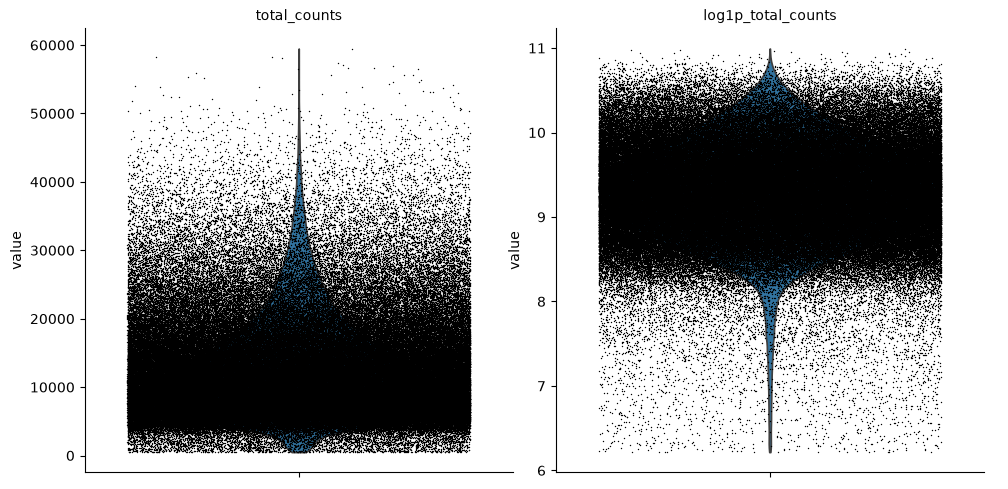

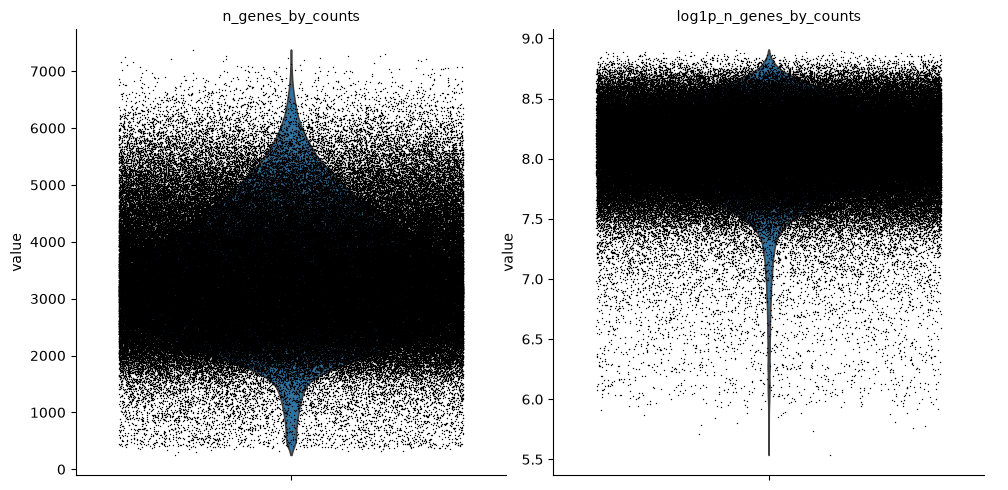

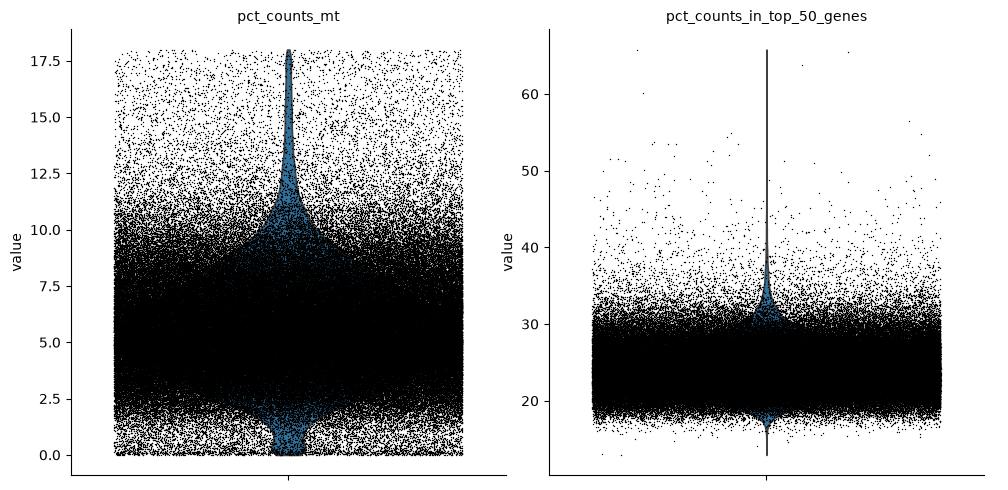

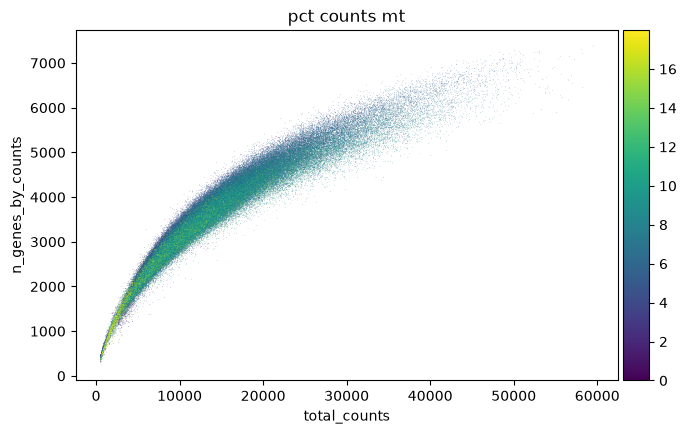

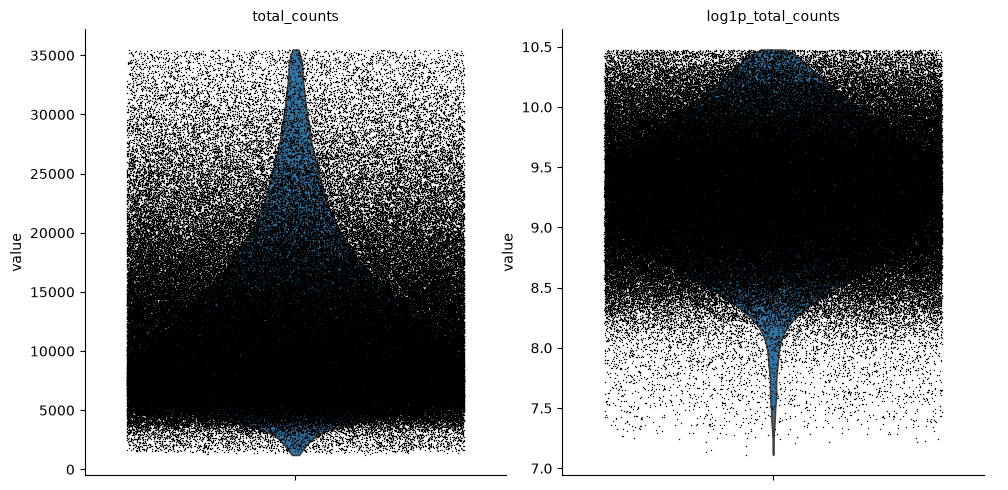

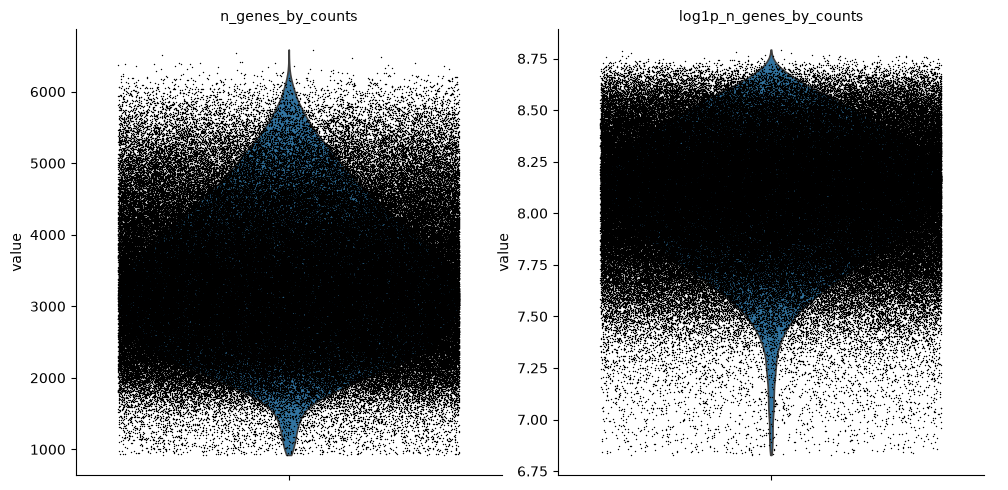

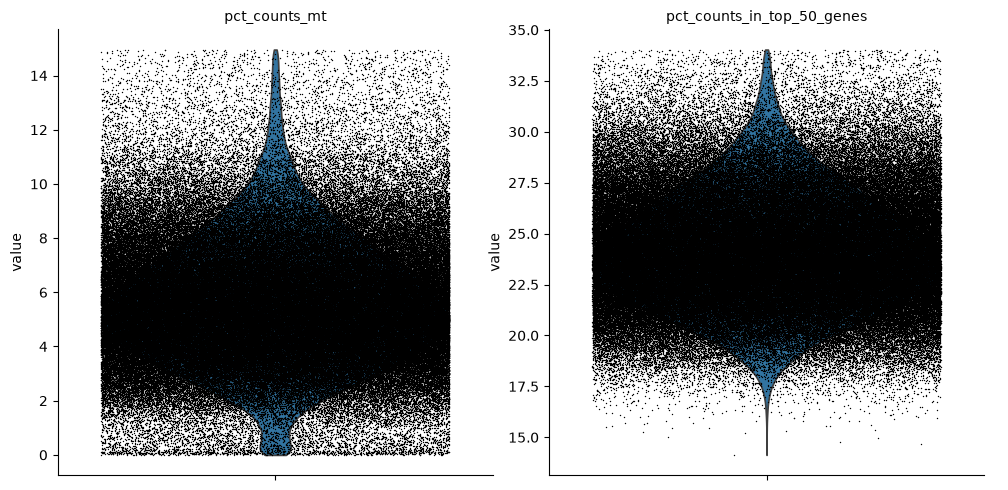

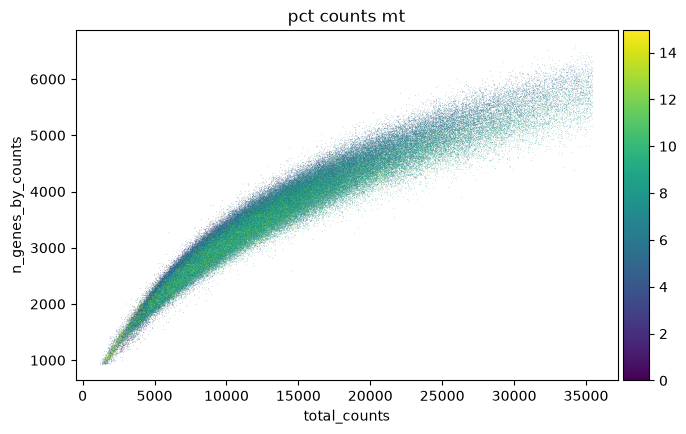

In [2]:
data_dir = Path("../../data/").resolve()
#adata = preprocessing.load_raw_adata(data_dir, metadata_path=data_dir/"RNA_metadata.csv", n_chunks=None, out_path=data_dir/"imported_data.h5ad")
adata = sc.read_h5ad(data_dir/"frangieh/rna.h5ad")
adata = preprocessing.run_qc(adata=adata, plots_dir=Path("../plots/qc").resolve(), out_path=data_dir/"qced_data.h5ad", min_genes=20)

In [3]:
adata = preprocessing.preprocess(adata)

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


In [7]:
adata.obs

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,...,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes,outlier
cell_name,,,,,,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,...,5.973810,3.618907,1402.0,7.246368,12.943130,2.0,1.098612,0.018464,3520,False
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,...,6.259582,4.864411,1363.0,7.218177,12.701519,0.0,0.000000,0.000000,3531,False
CELL_3,10X 3' v3 sequencing,Control,1,HLA-B_2,28821.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,...,7.111512,4.250373,3559.0,8.177516,12.348635,2.0,1.098612,0.006939,5541,False
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,...,6.781058,5.743375,2340.0,7.758334,15.272159,1.0,0.693147,0.006527,4086,False
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,...,6.342122,5.497382,1558.0,7.351800,15.105681,0.0,0.000000,0.000000,3178,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_218327,10X 3' v3 sequencing,Co-culture,4,nan,12722.0,CTSO_3;PIK3IP1_3;VDAC2_2;WNT7A_1,CTSO,cell_line_co-culture,True,melanoma,...,6.391917,4.684798,1701.0,7.439559,13.370540,0.0,0.000000,0.000000,3686,False
CELL_218328,10X 3' v3 sequencing,Co-culture,2,nan,11643.0,JAK2_3;SLC7A5P1_3,JAK2,cell_line_co-culture,True,melanoma,...,6.230482,4.354548,1630.0,7.396949,13.999828,2.0,1.098612,0.017178,3462,False
CELL_218329,10X 3' v3 sequencing,Co-culture,3,nan,12497.0,S100A6_2;SAT1_2;ONE_NON-GENE_SITE_177,control,cell_line_co-culture,True,melanoma,...,4.025352,0.440106,1924.0,7.562681,15.395695,0.0,0.000000,0.000000,3768,False


In [5]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.metrics import get_scorer_names
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import seaborn as sns
import numpy as np
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighte

In [8]:
X = adata.X[:,adata.var["highly_variable"].to_numpy()]
y = adata.obs["perturbation_2"]
X.shape, y.shape
#x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.1, shuffle=True, stratify=y)

((211345, 2084), (211345,))

In [9]:
def score_cv(estimator, X,y, scoring = ["accuracy", "average_precision", "f1_macro",]):
    scores = pd.DataFrame(cross_validate(estimator, X,y, scoring=scoring))
    return scores

In [10]:
classifier = LogisticRegression()

scores = score_cv(classifier, X,y)
print(scores)

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/mod

    fit_time  score_time  test_accuracy  test_average_precision  test_f1_macro
0  11.539018    0.322008       0.930564                0.955109       0.929485
1  11.072562    0.321451       0.930185                0.952602       0.928782
2  12.226111    0.325963       0.933213                0.954279       0.931740
3  11.698591    0.323541       0.922733                0.948047       0.921558
4  11.724294    0.328512       0.927204                0.951567       0.925666


In [11]:
classifier = RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=50)
scores = score_cv(classifier, X,y)
print(scores)

    fit_time  score_time  test_accuracy  test_average_precision  test_f1_macro
0  17.830797    0.832656       0.833732                0.934861       0.825057
1  16.600012    0.839593       0.829047                0.931387       0.820989
2  15.824849    0.847546       0.837470                0.934149       0.830229
3  16.670418    0.827959       0.820720                0.919913       0.815054
4  16.533625    0.822187       0.823653                0.929550       0.815382
